In [137]:
import pandas as pd
import pathlib
import numpy as np
from matplotlib import pyplot as plt
from pandas import DataFrame

In [138]:
TRACK = "sqlite:///../data/track2_good.db"
TRACK_2_SEGMENT_POINTS = [(923, 2590), (610, 2485), (635, 2780), (525, 2720), (880, 2790)]

In [139]:
df = pd.read_sql(
    """
    SELECT
        position_x,
        position_y,
        position_z
    FROM telemetry_samples
    WHERE distance_traveled != 0
    AND lap_number = 0
    ORDER BY id
    """,
    TRACK
)

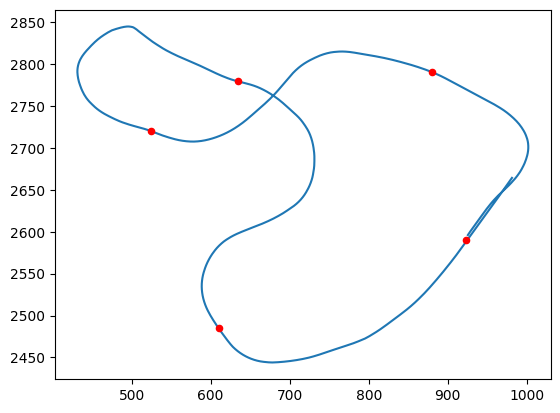

In [140]:
plt.plot(df['position_x'].values, df['position_z'].values)
plt.scatter([i[0] for i in TRACK_2_SEGMENT_POINTS], [i[1] for i in TRACK_2_SEGMENT_POINTS], c='red', s=20, zorder=5)
plt.show()

In [141]:
def get_index_nearest_position(point: tuple, positions_x: np.ndarray, positions_z: np.ndarray) -> int:
    smallest_distance = np.inf

    for i in range(positions_x.shape[0]):
        distance = np.sqrt(((point[0] - positions_x[i])**2 + (point[1] - positions_z[i])**2))
        if distance < smallest_distance:
            smallest_distance = distance
            index = i
    
    return index

In [142]:
def segment_labels(points: list, track: DataFrame):
    labels = []
    segment = 0

    for point in points:
        index = get_index_nearest_position(point, track['position_x'].values, track['position_z'].values)
        labels += [segment] * (index - len(labels))
        segment += 1
    
    
    return labels

df['segment'] = (segment_labels(TRACK_2_SEGMENT_POINTS, df) + [6] * df.shape[0])[:df.shape[0]]

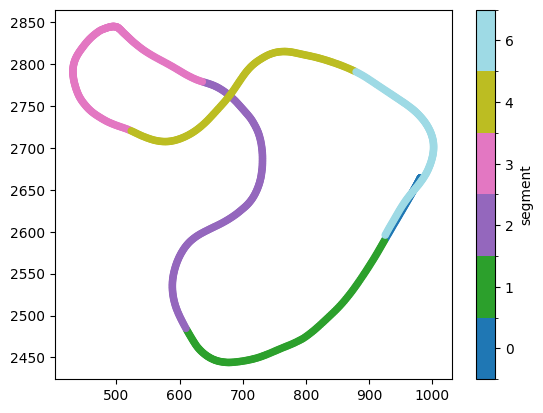

In [143]:
import numpy as np
from matplotlib.colors import BoundaryNorm

x = df["position_x"].to_numpy()
z = df["position_z"].to_numpy()
seg = df["segment"].to_numpy()

unique = np.unique(seg)
cmap = plt.get_cmap("tab20", len(unique))
norm = BoundaryNorm(np.arange(len(unique)+1) - 0.5, cmap.N)

mapping = {val: i for i, val in enumerate(unique)}
seg_mapped = np.array([mapping[v] for v in seg])

plt.plot(x, z, alpha=0.3)
sc = plt.scatter(x, z, c=seg_mapped, cmap=cmap, norm=norm, s=20, zorder=5)

cbar = plt.colorbar(sc, ticks=np.arange(len(unique)))
cbar.ax.set_yticklabels(unique)
cbar.set_label("segment")

plt.show()